<a href="https://colab.research.google.com/github/YashLadlapure/Daily_Prep/blob/main/F1_EDA_Dashboard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# CELL 1 — Import Libraries
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print('Libraries imported successfully!')

Libraries imported successfully!


In [6]:
# ============================================================
# CELL 2 — Load & Inspect Dataset
# ============================================================
# Upload f1.csv manually via Files panel (left sidebar) OR
# mount Google Drive if file is there
from google.colab import files
df = pd.read_csv('f1 (1).csv')

print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
print('\nData Types:')
print(df.dtypes)# ============================================================
# CELL 3 — Data Cleaning & Feature Engineering
# ============================================================

# 1. Convert lap_time_ms to seconds
df['lap_time_sec'] = df['lap_time_ms'] / 1000

# 2. Remove unrealistic lap times (keep 40s – 200s)
before = len(df)
df = df[(df['lap_time_sec'] >= 40) & (df['lap_time_sec'] <= 200)]
after = len(df)
print(f'Rows before outlier removal: {before}')
print(f'Rows after  outlier removal: {after}')
print(f'Removed: {before - after} rows')

# 3. Create lap type column
df['lap_type'] = df['pit_stop'].apply(lambda x: 'Pit Lap' if x > 0 else 'Normal Lap')

# 4. Position gain (grid vs finish)
if 'grid' in df.columns and 'positionOrder' in df.columns:
        df['position_gain'] = pd.to_numeric(df['grid'], errors='coerce') - df['positionOrder']

print('\nFeature engineering done!')
print('New columns added: lap_time_sec, lap_type, position_gain')
df[['lap_time_sec', 'lap_type']].head(10)
print('\nMissing Values per column:')
print(df.isna().sum())
print('\nBasic Stats:')
df.describe()

Shape: (372493, 17)

Columns: ['Unnamed: 0', 'raceId', 'driverId', 'lap', 'position', 'lap_time_ms', 'race_year', 'round', 'circuitId', 'race_name', 'race_date', 'race_time', 'pit_stop', 'tyre_age', 'constructorId', 'grid', 'positionOrder']

Data Types:
Unnamed: 0        int64
raceId            int64
driverId          int64
lap               int64
position          int64
lap_time_ms       int64
race_year         int64
round             int64
circuitId         int64
race_name        object
race_date        object
race_time        object
pit_stop          int64
tyre_age          int64
constructorId     int64
grid             object
positionOrder     int64
dtype: object
Rows before outlier removal: 372493
Rows after  outlier removal: 371712
Removed: 781 rows

Feature engineering done!
New columns added: lap_time_sec, lap_type, position_gain

Missing Values per column:
Unnamed: 0          0
raceId              0
driverId            0
lap                 0
position            0
lap_time_ms 

,Unnamed: 0,raceId,driverId,lap,position,lap_time_ms,race_year,round,circuitId,pit_stop,tyre_age,constructorId,positionOrder,lap_time_sec,position_gain
count,371712.000000,371712.000000,371712.000000,371712.000000,371712.000000,371712.000000,371712.000000,371712.000000,371712.000000,371712.000000,371712.000000,371712.000000,371712.000000,371712.000000,370646.000000
mean,186210.379939,964.194223,556.139358,30.156430,10.033348,95310.380752,2017.704481,10.784287,24.485521,0.034024,12.949168,72.158873,10.040679,95.310381,0.613969
std,107541.478363,183.360006,383.140287,18.196222,5.652087,16938.640544,4.764666,6.049384,24.514296,0.181290,10.285614,85.936369,5.662461,16.938641,4.818133
min,0.000000,337.000000,1.000000,1.000000,1.000000,55404.000000,2010.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,55.404000,-23.000000
25%,93065.750000,898.000000,20.000000,15.000000,5.000000,82855.000000,2013.000000,6.000000,7.000000,0.000000,5.000000,5.000000,5.000000,82.855000,-1.000000
50%,186181.500000,994.000000,818.000000,29.000000,10.000000,93464.000000,2018.000000,11.000000,15.000000,0.000000,11.000000,10.000000,10.000000,93.464000,1.000000
75%,279361.250000,1084.000000,840.000000,44.000000,15.000000,103874.000000,2022.000000,16.000000,32.000000,0.000000,18.000000,131.000000,15.000000,103.874000,3.000000
max,372492.000000,1171.000000,866.000000,87.000000,24.000000,199978.000000,2026.000000,24.000000,80.000000,1.000000,77.000000,217.000000,24.000000,199.978000,21.000000


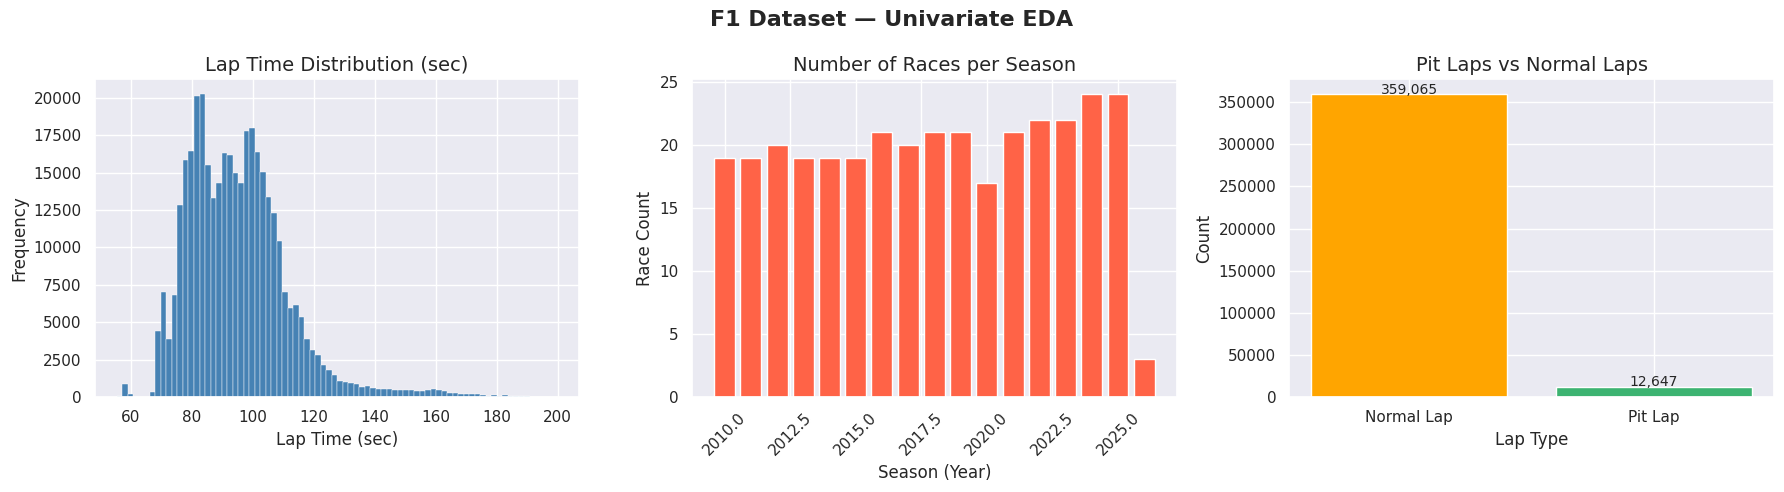

Saved: eda_univariate.png


In [7]:
# ============================================================
# CELL 4 — Univariate EDA Plots
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('F1 Dataset — Univariate EDA', fontsize=16, fontweight='bold')

# Plot 1: Lap time distribution
axes[0].hist(df['lap_time_sec'], bins=80, color='steelblue', edgecolor='white', linewidth=0.3)
axes[0].set_title('Lap Time Distribution (sec)')
axes[0].set_xlabel('Lap Time (sec)')
axes[0].set_ylabel('Frequency')

# Plot 2: Races per season
races_per_year = df.groupby('race_year')['raceId'].nunique().reset_index()
axes[1].bar(races_per_year['race_year'], races_per_year['raceId'], color='tomato', edgecolor='white')
axes[1].set_title('Number of Races per Season')
axes[1].set_xlabel('Season (Year)')
axes[1].set_ylabel('Race Count')
axes[1].tick_params(axis='x', rotation=45)

# Plot 3: Pit vs Normal lap count
lap_counts = df['lap_type'].value_counts()
axes[2].bar(lap_counts.index, lap_counts.values, color=['orange', 'mediumseagreen'], edgecolor='white')
axes[2].set_title('Pit Laps vs Normal Laps')
axes[2].set_xlabel('Lap Type')
axes[2].set_ylabel('Count')
for i, v in enumerate(lap_counts.values):
    axes[2].text(i, v + 500, f'{v:,}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('eda_univariate.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_univariate.png')

In [8]:
# ============================================================
# CELL 5 — Race-Level Aggregation & Save race_summary.csv
# ============================================================

race_summary = df.groupby(['raceId', 'race_year', 'race_name']).agg(
    laps        = ('lap', 'max'),
    avg_lap_sec = ('lap_time_sec', 'mean'),
    best_lap_sec= ('lap_time_sec', 'min'),
    pit_laps    = ('pit_stop', lambda x: (x > 0).sum()),
    total_laps  = ('lap', 'count')
).reset_index()

race_summary['pit_pct'] = (race_summary['pit_laps'] / race_summary['total_laps'] * 100).round(2)
race_summary['avg_lap_sec']  = race_summary['avg_lap_sec'].round(3)
race_summary['best_lap_sec'] = race_summary['best_lap_sec'].round(3)

race_summary.to_csv('race_summary.csv', index=False)
print('race_summary.csv saved!')
print(f'Shape: {race_summary.shape}')
race_summary.head(10)

race_summary.csv saved!
Shape: (331, 9)


,raceId,race_year,race_name,laps,avg_lap_sec,best_lap_sec,pit_laps,total_laps,pit_pct
0,337,2010,Bahrain Grand Prix,49,123.995,118.287,21,912,2.30
1,338,2010,Australian Grand Prix,58,99.992,88.358,27,918,2.94
2,339,2010,Malaysian Grand Prix,56,103.209,97.054,20,1039,1.92
3,340,2010,Chinese Grand Prix,56,116.436,102.061,67,983,6.82
4,341,2010,Spanish Grand Prix,66,89.306,84.357,28,1320,2.12
5,342,2010,Monaco Grand Prix,78,85.809,75.192,19,1381,1.38
6,343,2010,Turkish Grand Prix,58,93.885,89.165,27,1293,2.09
7,344,2010,Canadian Grand Prix,70,82.746,76.972,61,1445,4.22
8,345,2010,European Grand Prix,57,107.228,98.766,28,1250,2.24
9,346,2010,British Grand Prix,52,99.351,90.874,28,1133,2.47


In [9]:
# ============================================================
# CELL 6 — Driver-Level Aggregation & Save driver_summary.csv
# ============================================================

driver_summary = df.groupby(['race_year', 'driverId', 'constructorId']).agg(
    laps        = ('lap', 'count'),
    avg_lap_sec = ('lap_time_sec', 'mean'),
    best_lap_sec= ('lap_time_sec', 'min'),
    pit_laps    = ('pit_stop', lambda x: (x > 0).sum())
).reset_index()

driver_summary['pit_rate_pct'] = (driver_summary['pit_laps'] / driver_summary['laps'] * 100).round(2)
driver_summary['avg_lap_sec']  = driver_summary['avg_lap_sec'].round(3)
driver_summary['best_lap_sec'] = driver_summary['best_lap_sec'].round(3)

driver_summary.to_csv('driver_summary.csv', index=False)
print('driver_summary.csv saved!')
print(f'Shape: {driver_summary.shape}')
driver_summary.head(10)

driver_summary.csv saved!
Shape: (401, 8)


,race_year,driverId,constructorId,laps,avg_lap_sec,best_lap_sec,pit_laps,pit_rate_pct
0,2010,1,1,1000,99.153,73.851,26,2.60
1,2010,2,15,268,107.329,75.068,8,2.99
2,2010,3,131,1028,98.561,74.184,24,2.33
3,2010,4,6,1119,98.006,73.855,28,2.50
4,2010,5,205,919,102.907,77.161,23,2.50
5,2010,9,4,994,99.302,75.161,24,2.41
6,2010,10,166,818,101.122,77.695,21,2.57
7,2010,13,6,1073,98.576,75.330,28,2.61
8,2010,15,205,806,103.689,77.316,25,3.10
9,2010,16,10,1001,100.164,74.997,24,2.40


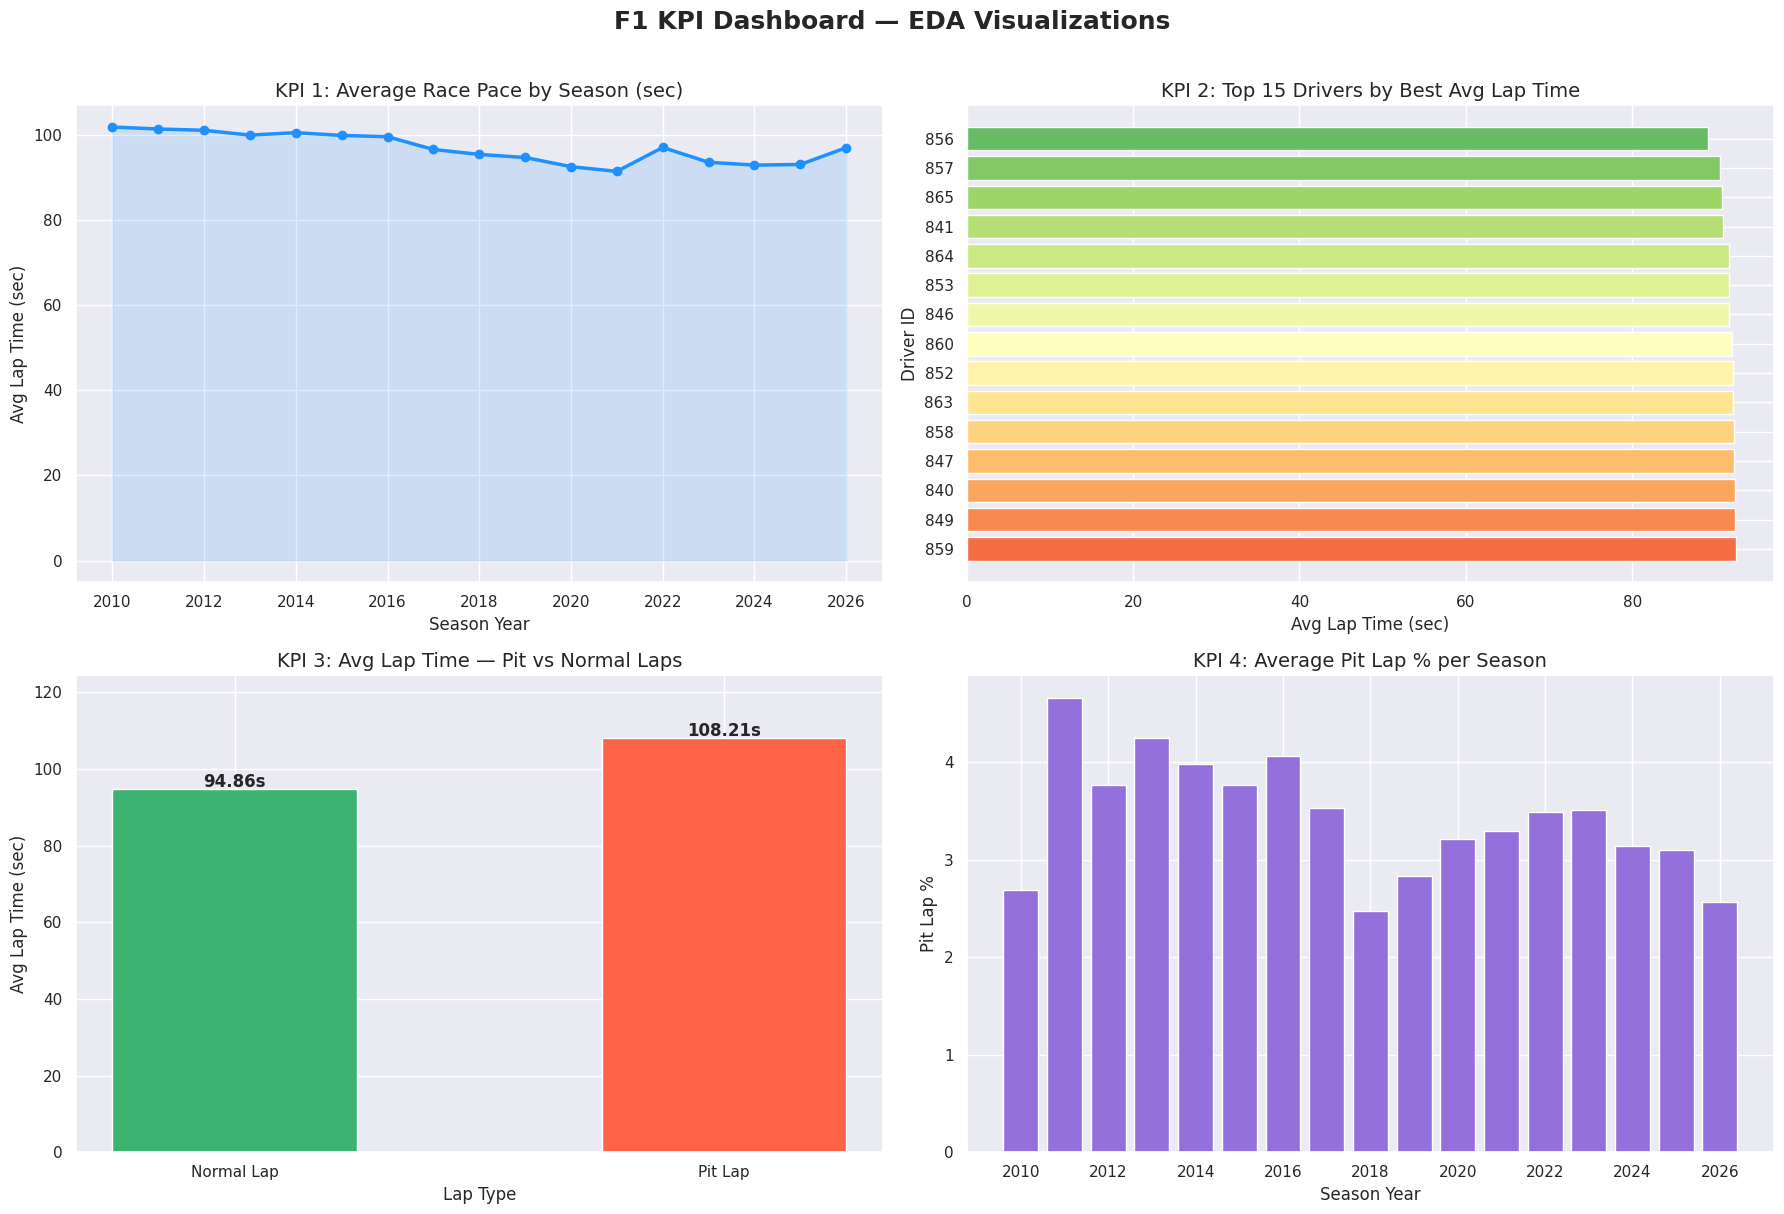

Saved: kpi_dashboard.png


In [10]:
# ============================================================
# CELL 7 — KPI Visualizations for Tableau Reference
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('F1 KPI Dashboard — EDA Visualizations', fontsize=18, fontweight='bold', y=1.01)

# --- KPI 1: Season-wise Average Lap Pace ---
year_pace = race_summary.groupby('race_year')['avg_lap_sec'].mean().reset_index()
axes[0, 0].plot(year_pace['race_year'], year_pace['avg_lap_sec'],
                marker='o', color='dodgerblue', linewidth=2.5, markersize=6)
axes[0, 0].fill_between(year_pace['race_year'], year_pace['avg_lap_sec'], alpha=0.15, color='dodgerblue')
axes[0, 0].set_title('KPI 1: Average Race Pace by Season (sec)')
axes[0, 0].set_xlabel('Season Year')
axes[0, 0].set_ylabel('Avg Lap Time (sec)')
axes[0, 0].xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# --- KPI 2: Top 15 Drivers by Avg Lap Time ---
top_drivers = driver_summary[driver_summary['laps'] >= 300] \
    .groupby('driverId')['avg_lap_sec'].mean() \
    .nsmallest(15).reset_index()
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, 15))
axes[0, 1].barh(top_drivers['driverId'].astype(str), top_drivers['avg_lap_sec'],
                color=colors, edgecolor='white')
axes[0, 1].invert_yaxis()
axes[0, 1].set_title('KPI 2: Top 15 Drivers by Best Avg Lap Time')
axes[0, 1].set_xlabel('Avg Lap Time (sec)')
axes[0, 1].set_ylabel('Driver ID')

# --- KPI 3: Pit vs Normal Lap Time Comparison ---
pit_avg = df.groupby('lap_type')['lap_time_sec'].mean().reset_index()
bar_colors = ['tomato' if t == 'Pit Lap' else 'mediumseagreen' for t in pit_avg['lap_type']]
bars = axes[1, 0].bar(pit_avg['lap_type'], pit_avg['lap_time_sec'],
                      color=bar_colors, edgecolor='white', width=0.5)
for bar in bars:
    axes[1, 0].text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.5,
                    f'{bar.get_height():.2f}s', ha='center', fontsize=12, fontweight='bold')
axes[1, 0].set_title('KPI 3: Avg Lap Time — Pit vs Normal Laps')
axes[1, 0].set_xlabel('Lap Type')
axes[1, 0].set_ylabel('Avg Lap Time (sec)')
axes[1, 0].set_ylim(0, max(pit_avg['lap_time_sec']) * 1.15)

# --- KPI 4: Pit Stop % per Season ---
pit_season = race_summary.groupby('race_year')['pit_pct'].mean().reset_index()
axes[1, 1].bar(pit_season['race_year'], pit_season['pit_pct'],
               color='mediumpurple', edgecolor='white')
axes[1, 1].set_title('KPI 4: Average Pit Lap % per Season')
axes[1, 1].set_xlabel('Season Year')
axes[1, 1].set_ylabel('Pit Lap %')
axes[1, 1].xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig('kpi_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: kpi_dashboard.png')